In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
stock_files = {'AAPL': 'data/AAPL.csv', 'MSFT': 'data/MSFT.csv', 'GOOGL': 'data/GOOGL.csv'}
etf_files = {'SPY': 'data/SPY.csv', 'QQQ': 'data/QQQ.csv'}
all_files = {**stock_files, **etf_files}

In [ ]:
all_data = []
for symbol, path in all_files.items():
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    
    df = df[df['Date'] >= '2015-01-01'].sort_values('Date')
    
    df['Symbol'] = symbol
    df['Daily Return'] = df['Adj Close'].pct_change()
    df['MA20'] = df['Adj Close'].rolling(window=20).mean()
    df['MA50'] = df['Adj Close'].rolling(window=50).mean()
    
    df['Cumulative Return'] = (1 + df['Daily Return'].fillna(0)).cumprod() - 1
    all_data.append(df)

combined_df = pd.concat(all_data)

In [6]:
combined_df.to_csv('final_stock_market_analysis.csv', index=False)

In [7]:
import plotly.express as px

# Create an interactive line chart for Cumulative Returns
fig = px.line(combined_df, x='Date', y='Cumulative Return', color='Symbol',
              title='Stock vs Benchmark: Cumulative Growth Performance',
              labels={'Cumulative Return': 'Growth (1.0 = 100%)'})

fig.update_layout(hovermode='x unified')
fig.show()

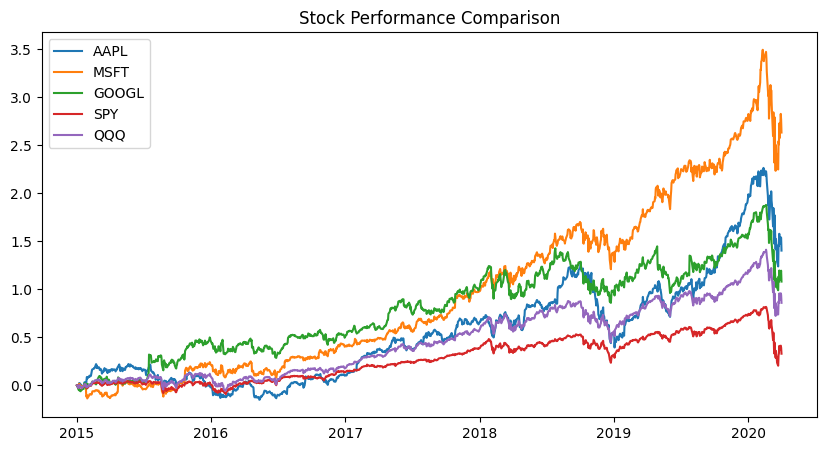

In [8]:
plt.figure(figsize=(10, 5))
for sym in combined_df['Symbol'].unique():
    subset = combined_df[combined_df['Symbol'] == sym]
    plt.plot(subset['Date'], subset['Cumulative Return'], label=sym)
plt.title('Stock Performance Comparison')
plt.legend()
plt.savefig('performance_growth.png')

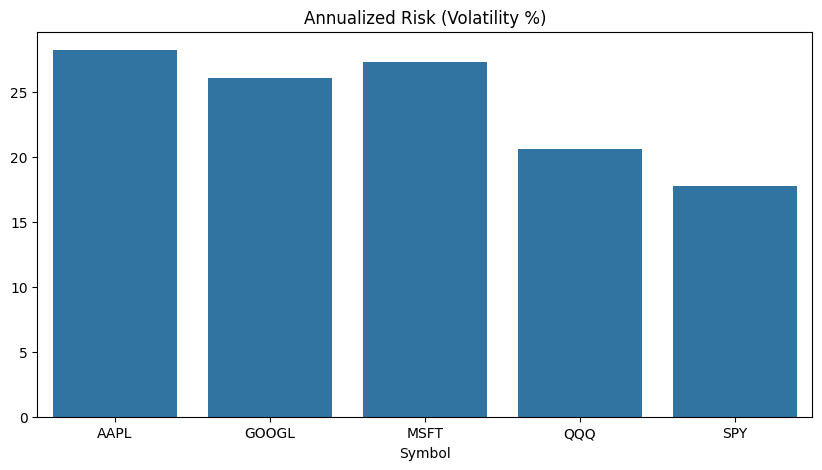

In [9]:
plt.figure(figsize=(10, 5))
vol = combined_df.groupby('Symbol')['Daily Return'].std() * (252**0.5) * 100
sns.barplot(x=vol.index, y=vol.values)
plt.title('Annualized Risk (Volatility %)')
plt.savefig('risk_analysis.png')

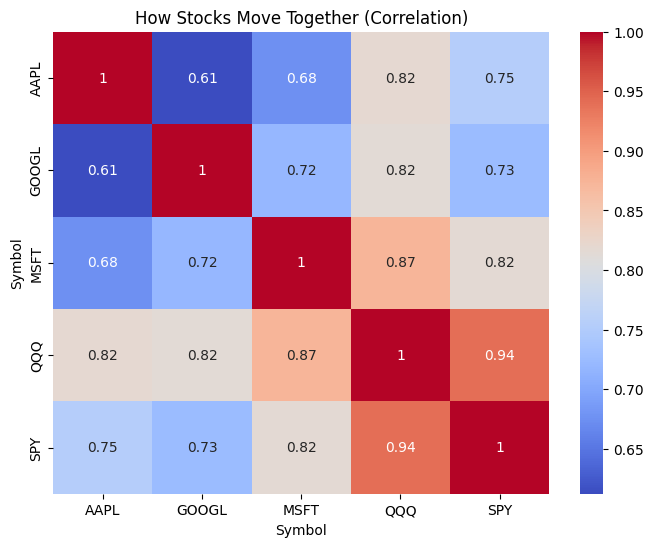

In [10]:
plt.figure(figsize=(8, 6))
returns = combined_df.pivot(index='Date', columns='Symbol', values='Daily Return')
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title('How Stocks Move Together (Correlation)')
plt.savefig('correlation_map.png')

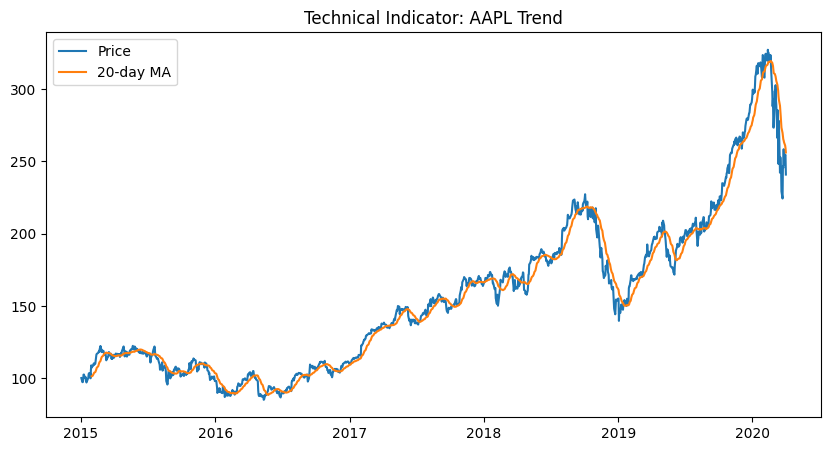

In [11]:
plt.figure(figsize=(10, 5))
aapl = combined_df[combined_df['Symbol'] == 'AAPL']
plt.plot(aapl['Date'], aapl['Adj Close'], label='Price')
plt.plot(aapl['Date'], aapl['MA20'], label='20-day MA')
plt.legend()
plt.title('Technical Indicator: AAPL Trend')
plt.savefig('technical_trends.png')